### Using prior knowledge
Edit the numbers marked `👈` and re-run.

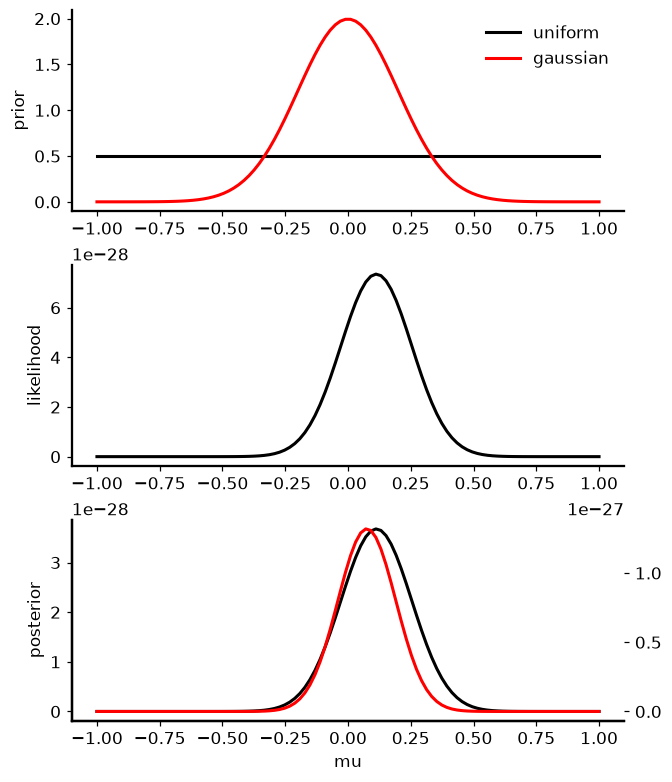

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import scipy.integrate as spi

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# Set up the same data and likelihood as before.
true_mu, true_sigma, N = 0, 1, 50
data = sps.norm.rvs(true_mu, true_sigma, size=N)
def uniform_prior(mu):   return sps.uniform.pdf(mu, loc=-1, scale=2)
def likelihood(data, mu): return sps.norm.pdf(data, loc=mu, scale=1)
def posterior(mu, data):  return uniform_prior(mu) * np.prod(likelihood(data, mu))

# A more informative prior: we think the mean is near 0.
prior_mean = 0.0    # 👈 try 0.1
prior_sd   = 0.2    # 👈 how sure we are
def gaussian_prior(mu):        return sps.norm.pdf(mu, prior_mean, prior_sd)
def posterior_gauss(mu, data): return gaussian_prior(mu) * np.prod(likelihood(data, mu))

mus = np.linspace(-1, 1, 100)
fig, ax = plt.subplots(3, 1, figsize=(6, 7), constrained_layout=True)
ax[0].plot(mus, uniform_prior(mus), "k", lw=2, label="uniform")
ax[0].plot(mus, gaussian_prior(mus), "r", lw=2, label="gaussian")
ax[0].set(ylabel="prior"); ax[0].legend()
ax[1].plot(mus, [np.prod(likelihood(data, m)) for m in mus], "k", lw=2); ax[1].set(ylabel="likelihood")
ax[2].plot(mus, [posterior(m, data) for m in mus], "k", lw=2, label="uniform prior")
ax[2].twinx().plot(mus, [posterior_gauss(m, data) for m in mus], "r", lw=2)
ax[2].set(xlabel="mu", ylabel="posterior")
plt.show()


In [2]:
# Compare Bayes factors from the two priors, on the SAME data
pH0_u = posterior(0, data);       pH1_u, _ = spi.quad(posterior, 0, 1, args=(data,))
pH0_g = posterior_gauss(0, data); pH1_g, _ = spi.quad(posterior_gauss, 0, 1, args=(data,))
print(f"Bayes factor BF01  --  uniform prior : {pH0_u / pH1_u:.3g}")
print(f"Bayes factor BF01  --  gaussian prior: {pH0_g / pH1_g:.3g}")


Bayes factor BF01  --  uniform prior : 2.6
Bayes factor BF01  --  gaussian prior: 3.76
